# SMS Spam collection (UCI)

In [1]:
# libraries

import pandas as pd
import numpy as np

In [2]:
# load dataset
df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# inspect dataset
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())

Shape: (5572, 5)

Columns:
 Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Missing values:
 v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [4]:
# drop unnecessary columns
df = df[['v1', 'v2']]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# rename column
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
#check class distribution
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
# converting lables to numeric
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# check missing values
df.isnull().sum()

df.dropna(inplace=True)

In [9]:
# remove duplicates
print("Before duplicates removal:", df.shape)

df.drop_duplicates(inplace=True)

print("After duplicates removal:", df.shape)

Before duplicates removal: (5572, 2)
After duplicates removal: (5169, 2)


In [10]:
# basic text cleaning
df['text'] = df['text'].str.lower()
df['text'] = df['text'].str.strip()

In [11]:
# final dataset check
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5169 non-null   int64 
 1   text    5169 non-null   object
dtypes: int64(1), object(1)
memory usage: 121.1+ KB


,label,text
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [12]:
df.to_csv("sms_cleaned.csv", index=False)

# Train-Test Split  (TF-IDF,  Bag of Words)

In [40]:
# load cleaned dataset

import pandas as pd

df = pd.read_csv("sms_cleaned.csv")
df.head()

X = df['text']
y = df['label']
print(df['label'].unique())
print(df['label'].isna().sum())

[0 1]
0


In [41]:
# Applying train -test Split

from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [42]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (4135,)
Test shape: (1034,)

Train label distribution:
label
0    0.873761
1    0.126239
Name: proportion, dtype: float64

Test label distribution:
label
0    0.873308
1    0.126692
Name: proportion, dtype: float64


In [17]:
# TF-IDF + Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),      # unigrams + bigrams
        max_df=0.9,
        min_df=2
    )),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9574468085106383
ROC-AUC: 0.9930046579256592

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       903
           1       0.99      0.67      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.84      0.89      1034
weighted avg       0.96      0.96      0.95      1034



In [18]:
# TF-IDF + Linear SVM
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_df=0.9,
        min_df=2
    )),
    ('clf', CalibratedClassifierCV(LinearSVC(), method='sigmoid'))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)
y_prob_svm = svm_pipeline.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9777562862669246
ROC-AUC: 0.9942769225567024

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.95      0.87      0.91       131

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [21]:
# TF-IDF Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_df=0.9,
        min_df=2
    )),
    ('clf', MultinomialNB())
])

nb_pipeline.fit(X_train, y_train)

y_pred_nb = nb_pipeline.predict(X_test)
y_prob_nb = nb_pipeline.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9690522243713733
ROC-AUC: 0.9878310635456029

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       1.00      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [22]:
# BoW + Naive Bayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

bow_nb_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_df=0.9,
        min_df=2
    )),
    ('clf', MultinomialNB())
])

bow_nb_pipeline.fit(X_train, y_train)

y_pred_bow_nb = bow_nb_pipeline.predict(X_test)
y_prob_bow_nb = bow_nb_pipeline.predict_proba(X_test)[:,1]

print("BoW + NB")
print("Accuracy:", accuracy_score(y_test, y_pred_bow_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bow_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bow_nb))

BoW + NB
Accuracy: 0.9845261121856866
ROC-AUC: 0.9791745919031556

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       903
           1       0.98      0.90      0.94       131

    accuracy                           0.98      1034
   macro avg       0.98      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [23]:
# BoW + Logistic Regression
from sklearn.linear_model import LogisticRegression

bow_lr_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_df=0.9,
        min_df=2
    )),
    ('clf', LogisticRegression(max_iter=1000))
])

bow_lr_pipeline.fit(X_train, y_train)

y_pred_bow_lr = bow_lr_pipeline.predict(X_test)
y_prob_bow_lr = bow_lr_pipeline.predict_proba(X_test)[:,1]

print("BoW + Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_bow_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bow_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bow_lr))

BoW + Logistic Regression
Accuracy: 0.9729206963249516
ROC-AUC: 0.9861910679414674

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       0.99      0.79      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [24]:
# BoW + Linear SVM
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

bow_svm_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_df=0.9,
        min_df=2
    )),
    ('clf', CalibratedClassifierCV(LinearSVC(), method='sigmoid'))
])

bow_svm_pipeline.fit(X_train, y_train)

y_pred_bow_svm = bow_svm_pipeline.predict(X_test)
y_prob_bow_svm = bow_svm_pipeline.predict_proba(X_test)[:,1]

print("BoW + SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_bow_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bow_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bow_svm))

BoW + SVM
Accuracy: 0.9816247582205029
ROC-AUC: 0.9843312791120354

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.99      0.86      0.92       131

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



# Result 

Contrary to common expectations, Bag of Words combined with Multinomial Naive Bayes outperformed TF-IDF across most evaluation metrics. This suggests that for short-text classification tasks such as SMS spam detection, raw term frequency features may capture discriminative patterns more effectively.


| Feature | Model               | Accuracy  | Spam Precision | Spam Recall | Spam F1  | ROC-AUC |
| ------- | ------------------- | --------- | -------------- | ----------- | -------- | ------- |
| TF-IDF  | Logistic Regression | 0.957     | 0.99           | 0.67        | 0.80     | 0.993   |
| TF-IDF  | Naive Bayes         | 0.969     | 1.00           | 0.76        | 0.86     | 0.988   |
| TF-IDF  | Linear SVM          | 0.977     | 0.95           | 0.87        | 0.91     | 0.994   |
| BoW     | Logistic Regression | 0.973     | 0.99           | 0.79        | 0.88     | 0.986   |
| BoW     | Naive Bayes         | 0.985     | 0.98           | 0.90        | 0.94     | 0.979   |
| BoW     | Linear SVM          | 0.982     | 0.99           | 0.86        | 0.92     | 0.984   |


Final Selected Model: Bag of Words + Multinomial Naive Bayes


In [25]:
# VISUALAITATION
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 10

# Create results dataframe manually from your experiments
data = {
    "Model": [
        "TFIDF + LR",
        "TFIDF + NB",
        "TFIDF + SVM",
        "BoW + LR",
        "BoW + NB",
        "BoW + SVM"
    ],
    "Accuracy": [0.957, 0.969, 0.977, 0.973, 0.985, 0.982],
    "Spam_Recall": [0.67, 0.76, 0.87, 0.79, 0.90, 0.86],
    "Spam_F1": [0.80, 0.86, 0.91, 0.88, 0.94, 0.92]
}

results_df = pd.DataFrame(data)
results_df

,Model,Accuracy,Spam_Recall,Spam_F1
0,TFIDF + LR,0.957,0.67,0.80
1,TFIDF + NB,0.969,0.76,0.86
2,TFIDF + SVM,0.977,0.87,0.91
3,BoW + LR,0.973,0.79,0.88
4,BoW + NB,0.985,0.90,0.94
5,BoW + SVM,0.982,0.86,0.92


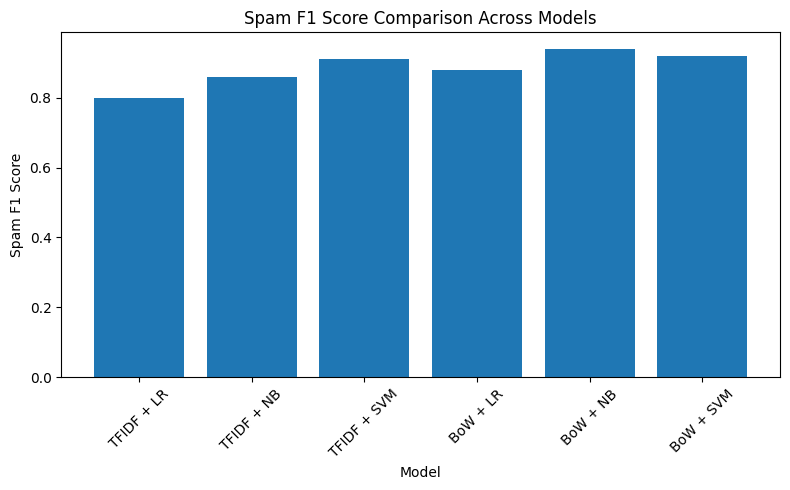

In [26]:
# Spam F1 Comparison
plt.figure()
plt.bar(results_df["Model"], results_df["Spam_F1"])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Spam F1 Score")
plt.title("Spam F1 Score Comparison Across Models")
plt.tight_layout()
plt.show()

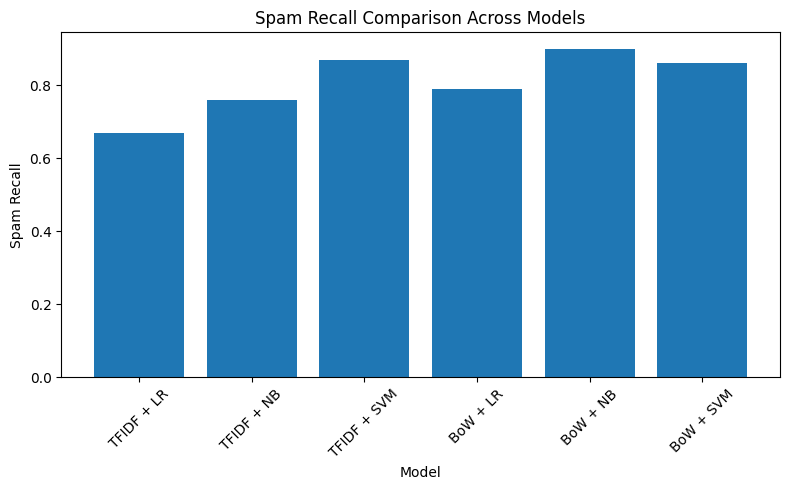

In [27]:
# Spam Recall Comparison
plt.figure()
plt.bar(results_df["Model"], results_df["Spam_Recall"])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Spam Recall")
plt.title("Spam Recall Comparison Across Models")
plt.tight_layout()
plt.show()

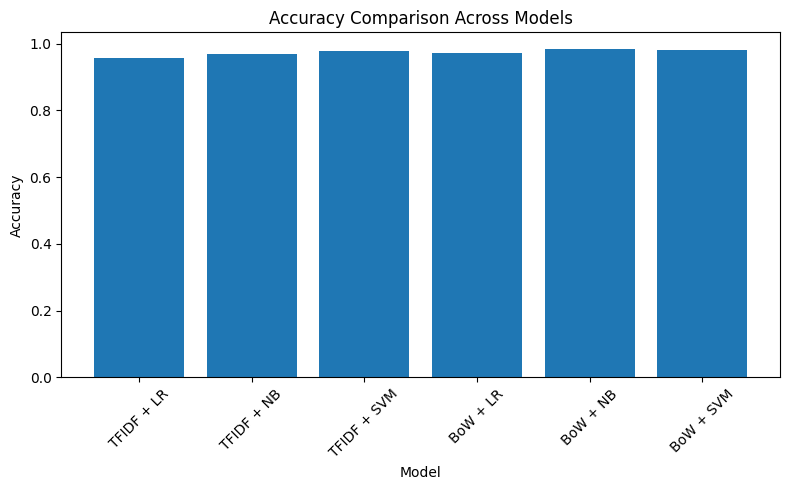

In [28]:
# Accuracy Comparison
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Across Models")
plt.tight_layout()
plt.show()

# Validate the Final Model

In [29]:
# Cross-Validation 5-fold cross-validation on the full dataset

from sklearn.model_selection import cross_val_score

final_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_df=0.9,
        min_df=2
    )),
    ('clf', MultinomialNB())
])

cv_accuracy = cross_val_score(final_pipeline, X, y, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(final_pipeline, X, y, cv=5, scoring='f1')

print("Cross-Validation Accuracy:", cv_accuracy.mean())
print("Cross-Validation F1:", cv_f1.mean())

Cross-Validation Accuracy: 0.9845229290287065
Cross-Validation F1: 0.9365811248351692


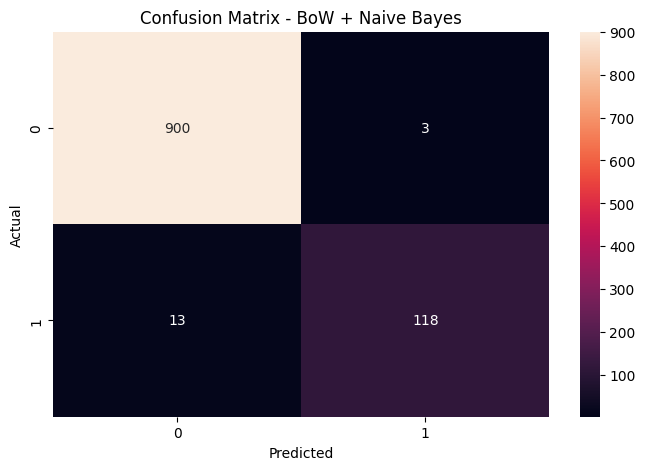

In [30]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BoW + Naive Bayes")
plt.show()

In [31]:
# Feature Importance
import numpy as np

vectorizer = final_pipeline.named_steps['vectorizer']
classifier = final_pipeline.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()

# Get top spam-indicative words
spam_class = 1
topn = 20

top_spam_indices = np.argsort(classifier.feature_log_prob_[spam_class])[-topn:]
top_spam_words = [feature_names[i] for i in top_spam_indices]

print("Top words indicating spam:")
print(top_spam_words)

Top words indicating spam:
['contact', '150p', 'urgent', 'win', 'won', 'send', 'uk', 'new', 'cash', 'just', 'prize', 'www', 'claim', 'reply', 'stop', 'mobile', 'text', 'txt', 'ur', 'free']


In [32]:
# Save the final model 
import joblib

joblib.dump(final_pipeline, "spam_classifier_model.pkl")
joblib.dump(bow_nb_pipeline, "bow_nb_pipeline.pkl")

['bow_nb_pipeline.pkl']

# Transformer based model

In [43]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
# Convert to HuggingFace Dataset
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": list(X_train),
    "label": list(y_train)
})

test_dataset = Dataset.from_dict({
    "text": list(X_test),
    "label": list(y_test)
})
print(len(train_dataset))
print(len(test_dataset))

4135
1034


In [49]:
# Load DistilBERT Tokenizer

from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [50]:
# Tokenization Function
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/4135 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

In [51]:
# Load DistilBERT Model

from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [53]:
# Training Arguments (CPU)
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./final_distilbert_output",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [55]:
# Metrics
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

In [56]:
# Train

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

# Evaluate
results = trainer.evaluate()
print(results)

C:\Users\neetu\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.210095
100,0.068819
150,0.055870
200,0.058344
250,0.060164
300,0.019337
350,0.050658
400,0.037647
450,0.023873
500,0.024190


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\neetu\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\neetu\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.02540522813796997, 'eval_accuracy': 0.9932301740812379, 'eval_precision': 0.9920634920634921, 'eval_recall': 0.9541984732824428, 'eval_f1': 0.9727626459143969, 'eval_runtime': 97.3549, 'eval_samples_per_second': 10.621, 'eval_steps_per_second': 0.668, 'epoch': 3.0}


In [57]:
trainer.save_model("./final_distilbert_model")
tokenizer.save_pretrained("./final_distilbert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_distilbert_model\\tokenizer_config.json',
 './final_distilbert_model\\tokenizer.json')

In [58]:
# comparision table
import pandas as pd

results = {
    "Feature": [
        "TF-IDF", "TF-IDF", "TF-IDF",
        "BoW", "BoW", "BoW",
        "Transformer"
    ],
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "DistilBERT"
    ],
    "Accuracy": [
        0.957, 0.969, 0.977,
        0.973, 0.985, 0.982,
        0.993
    ],
    "Spam Precision": [
        0.99, 1.00, 0.95,
        0.99, 0.98, 0.99,
        0.992
    ],
    "Spam Recall": [
        0.67, 0.76, 0.87,
        0.79, 0.90, 0.86,
        0.954
    ],
    "Spam F1": [
        0.80, 0.86, 0.91,
        0.88, 0.94, 0.92,
        0.973
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df

,Feature,Model,Accuracy,Spam Precision,Spam Recall,Spam F1
0,TF-IDF,Logistic Regression,0.957,0.990,0.670,0.800
1,TF-IDF,Naive Bayes,0.969,1.000,0.760,0.860
2,TF-IDF,Linear SVM,0.977,0.950,0.870,0.910
3,BoW,Logistic Regression,0.973,0.990,0.790,0.880
4,BoW,Naive Bayes,0.985,0.980,0.900,0.940
5,BoW,Linear SVM,0.982,0.990,0.860,0.920
6,Transformer,DistilBERT,0.993,0.992,0.954,0.973


C:\Users\neetu\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


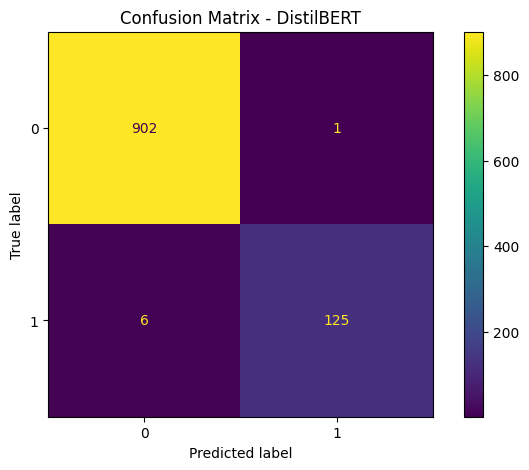

In [59]:
# Confusion matrix Distilbert

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - DistilBERT")
plt.show()

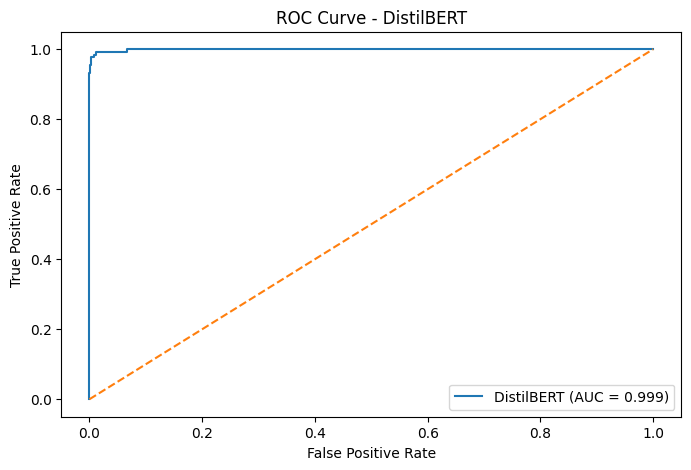

In [60]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

# Get probabilities for spam class (usually class index 1)
probs = predictions.predictions[:, 1]

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"DistilBERT (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.legend()
plt.show()

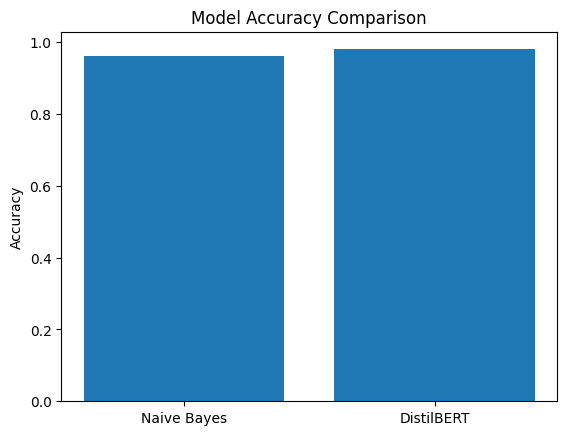

In [1]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "DistilBERT"]
accuracy = [0.96, 0.98]

plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

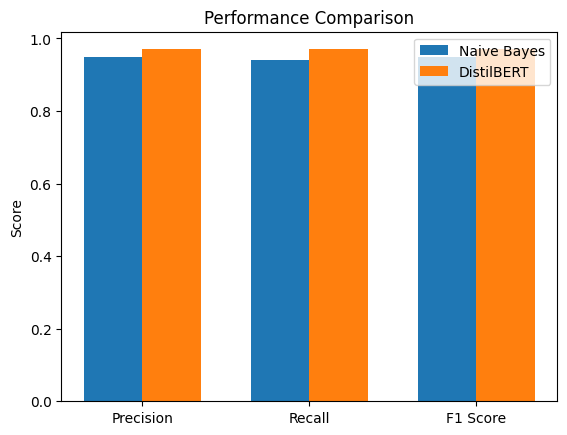

In [2]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Precision", "Recall", "F1 Score"]

naive_bayes = [0.95, 0.94, 0.95]
distilbert = [0.97, 0.97, 0.97]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, naive_bayes, width, label="Naive Bayes")
plt.bar(x + width/2, distilbert, width, label="DistilBERT")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Performance Comparison")
plt.legend()

plt.show()